In [1]:
# from google.colab import drive
import os

# Mount Google Drive
# drive.mount('/content/drive')

In [2]:
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor
import torch.nn.functional as F

In [3]:
import re

def sorted_alphanumeric(data):

    convert = lambda text: int(text) if text.isdigit() else text.lower()
    alphanum_key = lambda key: [convert(c) for c in re.split('([0-9]+)', key)]
    return sorted(data, key=alphanum_key)

In [4]:
class ImageDataset(Dataset):
    def __init__(self, low_path, high_path, size = 256):
        self.size = size
        self.low_path = low_path
        self.high_path = high_path
        self.high_files = sorted_alphanumeric(os.listdir(high_path))
        self.low_files = sorted_alphanumeric(os.listdir(low_path))

    def __len__(self):
        return len(self.low_files)


    def __getitem__(self, idx):

        high_img_path = os.path.join(self.high_path, self.high_files[idx])
        low_img_path = os.path.join(self.low_path, self.low_files[idx])

        high_img = cv2.imread(high_img_path, 1)
        high_img = cv2.cvtColor(high_img, cv2.COLOR_BGR2RGB)
        high_img = cv2.resize(high_img, (self.size, self.size))
        high_img = high_img.astype('float32') / 255.0

        low_img = cv2.imread(low_img_path, 1)
        low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
        low_img = cv2.resize(low_img, (self.size//4, self.size//4))
        low_img = low_img.astype('float32') / 255.0

        return {
            'high_img': ToTensor()(high_img),
            'low_img': ToTensor()(low_img)
        }

In [5]:
high_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Train set\high_res'
low_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Train set\low_res'
test_high_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Test set\high_res'
test_low_res_path = r'C:\Users\User\Desktop\jheng_wei\Lab02\Data\Test set\low_res'

# Create dataset instance
dataset = ImageDataset(low_res_path, high_res_path)
test_set = ImageDataset(test_low_res_path, test_high_res_path)

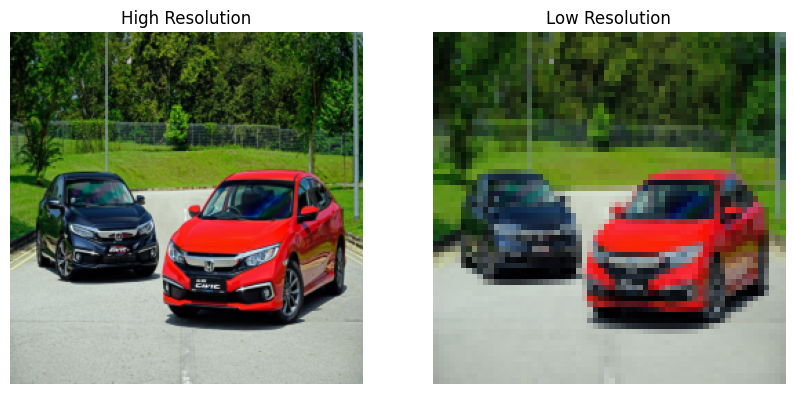

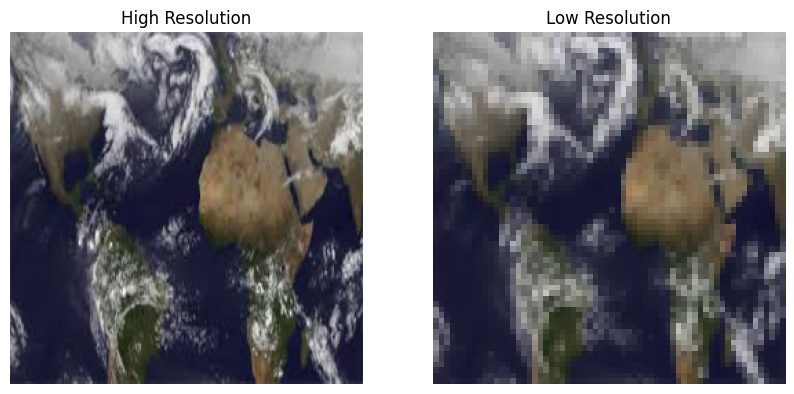

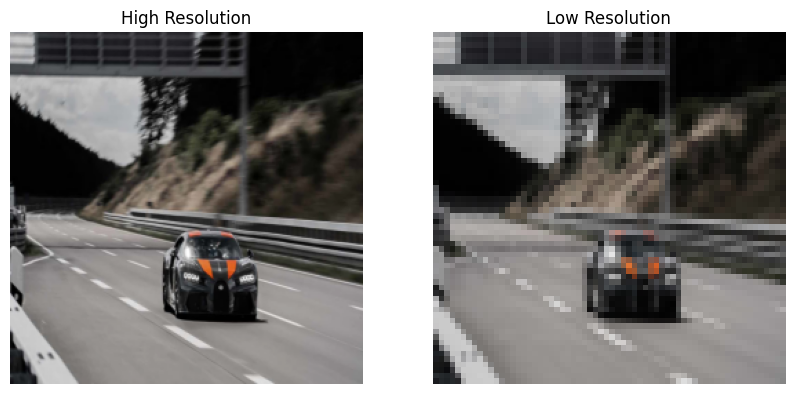

In [6]:
import matplotlib.pyplot as plt
import cv2
num_pairs_to_print = 3

for idx in range(num_pairs_to_print):
    sample = dataset[idx]
    high_img, low_img = sample['high_img'], sample['low_img']
    #Convert the pytorch tensors to numpy arrays
    #Matplotlib expects the images to be in the format : height, width, channels whereas the the pytroch tensor has it in the form of channels, height, width
    #After doing this we convert to the numpy array
    high_img_np = high_img.permute(1, 2, 0).numpy() if high_img.shape[0] == 3 else high_img.numpy()
    low_img_np = low_img.permute(1, 2, 0).numpy() if low_img.shape[0] == 3 else low_img.numpy()

    # Plot high-resolution and low-resolution images
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(high_img_np)
    plt.title('High Resolution')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(low_img_np)
    plt.title('Low Resolution')
    plt.axis('off')

    plt.show()


In [7]:
from torch.utils.data import random_split

print("Number of high-resolution images:", len(dataset.high_files))
print("Number of low-resolution images:", len(dataset.low_files))
print("Number of Test high-resolution images:", len(test_set.high_files))
print("Number of Test low-resolution images:", len(test_set.low_files))

train_size = int(0.8 * len(dataset))
val_size = int(0.2 * len(dataset))
# Split the dataset into train, validation sets
train_set, val_set = random_split(dataset, [train_size, val_size])
print("Length of training set is: ", len(train_set))
print("Length of validation set is: ", len(val_set))
print("Length of testing set is: ", len(test_set))


Number of high-resolution images: 360
Number of low-resolution images: 360
Number of Test high-resolution images: 40
Number of Test low-resolution images: 40
Length of training set is:  288
Length of validation set is:  72
Length of testing set is:  40


In [8]:
batch_size = 8
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)


MODEL

In [9]:
# using gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#build your model here
class RRDBNet(nn.Module):
    def __init__(self, in_channels, out_channels, num_features, num_blocks, num_grow_channels=32):
        super(RRDBNet, self).__init__()
        self.conv_first = nn.Conv2d(in_channels, num_features, 3, 1, 1)
        self.body = nn.Sequential(*[RRDB(num_features, num_grow_channels) for _ in range(num_blocks)])
        self.conv_body = nn.Conv2d(num_features, num_features, 3, 1, 1)
        self.conv_up1 = nn.Conv2d(num_features, num_features, 3, 1, 1)
        self.conv_up2 = nn.Conv2d(num_features, num_features, 3, 1, 1)
        self.conv_hr = nn.Conv2d(num_features, num_features, 3, 1, 1)
        self.conv_last = nn.Conv2d(num_features, out_channels, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        feat = self.conv_first(x)
        body_feat = self.conv_body(self.body(feat))
        feat = feat + body_feat
        feat = self.lrelu(self.conv_up1(F.interpolate(feat, scale_factor=2, mode='nearest')))
        feat = self.lrelu(self.conv_up2(F.interpolate(feat, scale_factor=2, mode='nearest')))
        out = self.conv_last(self.lrelu(self.conv_hr(feat)))
        return out

class RRDB(nn.Module):
    def __init__(self, num_features, num_grow_channels):
        super(RRDB, self).__init__()
        self.rdb1 = RDB(num_features, num_grow_channels)
        self.rdb2 = RDB(num_features, num_grow_channels)
        self.rdb3 = RDB(num_features, num_grow_channels)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x

class RDB(nn.Module):
    def __init__(self, num_features, num_grow_channels):
        super(RDB, self).__init__()
        self.conv1 = nn.Conv2d(num_features, num_grow_channels, 3, 1, 1)
        self.conv2 = nn.Conv2d(num_features + num_grow_channels, num_grow_channels, 3, 1, 1)
        self.conv3 = nn.Conv2d(num_features + 2 * num_grow_channels, num_grow_channels, 3, 1, 1)
        self.conv4 = nn.Conv2d(num_features + 3 * num_grow_channels, num_features, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        return x4 * 0.2 + x

# Instantiate the model
model = RRDBNet(in_channels=3, out_channels=3, num_features=64, num_blocks=23, num_grow_channels=32)


In [10]:
# Function to calculate PSNR (Peak Signal-to-Noise Ratio)
def calculate_psnr(img1, img2):
    mse = nn.functional.mse_loss(img1, img2)
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()

In [11]:
####################  implement your optimizer ###################################
## you can use any training methods if you want (ex:lr decay, weight decay.....)
# Perceptual Loss
class VGGLoss(nn.Module):
    def __init__(self):
        super(VGGLoss, self).__init__()
        vgg = models.vgg19(pretrained=True).features[:35].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg.to(device)
        self.criterion = nn.MSELoss()

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return self.criterion(sr_feat, hr_feat)

# Loss functions
content_criterion = nn.L1Loss()
perceptual_criterion = VGGLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200000, gamma=0.5)

# Training loop
num_epochs = 100
psnr_best = 0.0

model = model.to(device)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for data in train_loader:
        low_img, high_img = data['low_img'].to(device), data['high_img'].to(device)

        optimizer.zero_grad()

        outputs = model(low_img)

        content_loss = content_criterion(outputs, high_img)
        perceptual_loss = perceptual_criterion(outputs, high_img)
        loss = content_loss + 0.1 * perceptual_loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    # Validation phase
    model.eval()
    val_loss = 0
    psnr_total = 0
    with torch.no_grad():
        for data in val_loader:
            low_img, high_img = data['low_img'].to(device), data['high_img'].to(device)

            outputs = model(low_img)

            val_loss += content_criterion(outputs, high_img).item()
            psnr_total += calculate_psnr(outputs, high_img)

    epoch_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_psnr = psnr_total / len(val_loader)

    if avg_psnr > psnr_best:
        psnr_best = avg_psnr
        print("Model saved")
        torch.save(model.state_dict(), "model.pth")

    print(f'Epoch {epoch + 1}  Train Loss: {epoch_loss:.4f} | Val Loss: {avg_val_loss:.4f} | PSNR: {avg_psnr:.2f} dB')

c:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\User/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:04<00:00, 117MB/s] 


Model saved
Epoch 1  Train Loss: 0.5192 | Val Loss: 0.0949 | PSNR: 17.07 dB
Model saved
Epoch 2  Train Loss: 0.3741 | Val Loss: 0.0806 | PSNR: 18.56 dB
Model saved
Epoch 3  Train Loss: 0.3221 | Val Loss: 0.0713 | PSNR: 19.43 dB
Model saved
Epoch 4  Train Loss: 0.2958 | Val Loss: 0.0553 | PSNR: 21.02 dB
Epoch 5  Train Loss: 0.2789 | Val Loss: 0.0603 | PSNR: 20.87 dB
Model saved
Epoch 6  Train Loss: 0.2706 | Val Loss: 0.0551 | PSNR: 21.44 dB
Model saved
Epoch 7  Train Loss: 0.2607 | Val Loss: 0.0493 | PSNR: 22.03 dB
Epoch 8  Train Loss: 0.2577 | Val Loss: 0.0565 | PSNR: 21.39 dB
Model saved
Epoch 9  Train Loss: 0.2521 | Val Loss: 0.0508 | PSNR: 22.24 dB
Model saved
Epoch 10  Train Loss: 0.2453 | Val Loss: 0.0497 | PSNR: 22.39 dB
Model saved
Epoch 11  Train Loss: 0.2381 | Val Loss: 0.0473 | PSNR: 22.44 dB
Epoch 12  Train Loss: 0.2351 | Val Loss: 0.0520 | PSNR: 22.13 dB
Epoch 13  Train Loss: 0.2377 | Val Loss: 0.0516 | PSNR: 22.24 dB
Model saved
Epoch 14  Train Loss: 0.2301 | Val Loss: 0.0

C:\Users\User\AppData\Local\Temp\ipykernel_19480\2739717022.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("model.pth", map_location=device)
Cli

PSNR for the testing data: 24.00 dB


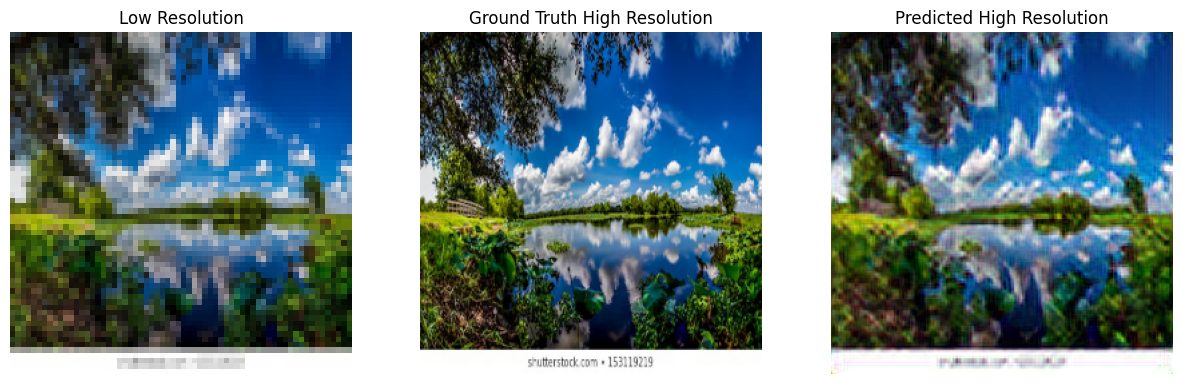

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15610743..1.108395].


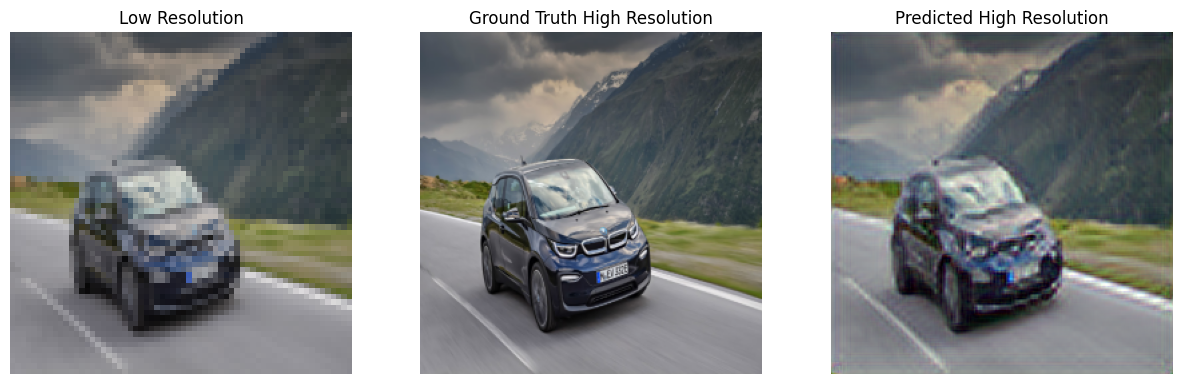

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19447485..1.1182773].


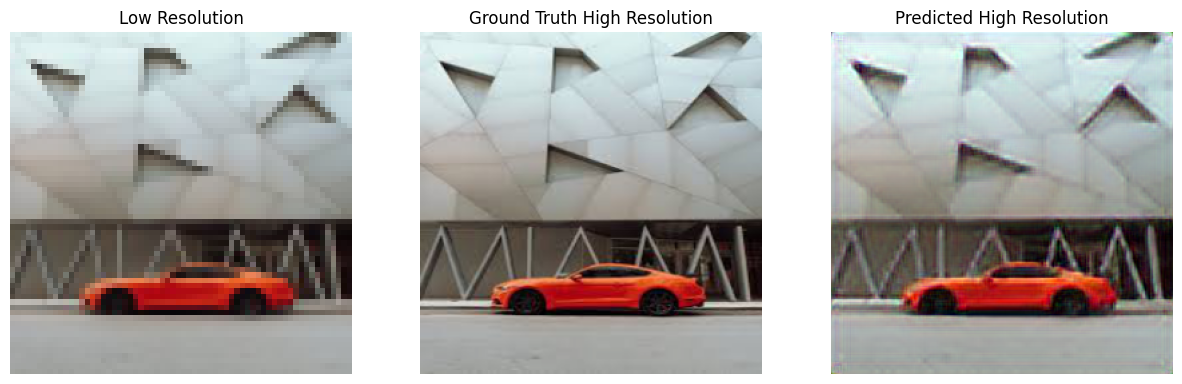

In [12]:
# Instantiate the model
test_model = RRDBNet(in_channels=3, out_channels=3, num_features=64, num_blocks=23, num_grow_channels=32)

# Load the state dict
state_dict = torch.load("model.pth", map_location=device)

# Load the state dict into the model
test_model.load_state_dict(state_dict)

# Move the model to the correct device
test_model = test_model.to(device)

# Set the model to evaluation mode
test_model.eval()

total_test_psnr = 0.0

# Run the model to get the reconstructed high-resolution images
with torch.no_grad():
    for test_batch in test_loader:
        # Move the low-res and high-res images to the same device as the model
        low_img = test_batch['low_img'].to(device)
        high_img = test_batch['high_img'].to(device)
        predicted_img = test_model(low_img)
        # Calculate PSNR for the current batch and accumulate the results
        psnr_value = calculate_psnr(predicted_img, high_img)
        total_test_psnr += psnr_value

test_psnr = total_test_psnr / len(test_loader)
print(f"PSNR for the testing data: {test_psnr:.2f} dB")

# Convert the tensors back to numpy arrays for visualization
high_img_np = high_img.cpu().permute(0, 2, 3, 1).numpy()  # (batch_size, height, width, channels)
low_img_np = low_img.cpu().permute(0, 2, 3, 1).numpy()    # (batch_size, height, width, channels)
predicted_img_np = predicted_img.cpu().permute(0, 2, 3, 1).numpy()  # (batch_size, height, width, channels)

# Plot some sample results
num_samples = 3  # Adjust this to show more/less samples
for i in range(num_samples):
    plt.figure(figsize=(15, 5))

    # Low resolution image
    plt.subplot(1, 3, 1)
    plt.imshow(low_img_np[i])
    plt.title('Low Resolution')
    plt.axis('off')

    # Ground truth high resolution image
    plt.subplot(1, 3, 2)
    plt.imshow(high_img_np[i])
    plt.title('Ground Truth High Resolution')
    plt.axis('off')

    # Predicted high resolution image
    plt.subplot(1, 3, 3)
    plt.imshow(predicted_img_np[i])
    plt.title('Predicted High Resolution')
    plt.axis('off')

    plt.show()